# 심화 실습 1: 다층 신경망을 활용한 다중 분류 (Deep Multi-class Classification)

## 학습 목표
- Hidden Layer를 추가하여 더 복잡한 패턴 학습
- ReLU, Dropout 등 다양한 기법 활용
- 학습 과정을 시각화하여 모델 성능 분석
- 과적합(Overfitting) 방지 기법 이해

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine  # Wine 데이터셋 (13개 특성, 3개 클래스)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정 (Google Colab)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch 버전: {torch.__version__}")
print(f"사용 가능한 디바이스: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 버전: 2.10.0+cpu
사용 가능한 디바이스: cpu


데이터 준비 및 전처리

In [2]:
wine = load_wine()
# print(wine.data, wine.target)
X, y = wine.data, wine.target
print(X.shape)    # 전체 데이터 수
print(X.shape[1]) # 특성 수
print(np.unique(y))
print(len(np.unique(y)))  # class 수
print(np.bincount(y))     # 클래스 별 분포

(178, 13)
13
[0 1 2]
3
[59 71 48]


In [3]:
X_temp, x_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [4]:
x_train[:5]

array([[1.336e+01, 2.560e+00, 2.350e+00, 2.000e+01, 8.900e+01, 1.400e+00,
        5.000e-01, 3.700e-01, 6.400e-01, 5.600e+00, 7.000e-01, 2.470e+00,
        7.800e+02],
       [1.305e+01, 1.730e+00, 2.040e+00, 1.240e+01, 9.200e+01, 2.720e+00,
        3.270e+00, 1.700e-01, 2.910e+00, 7.200e+00, 1.120e+00, 2.910e+00,
        1.150e+03],
       [1.285e+01, 3.270e+00, 2.580e+00, 2.200e+01, 1.060e+02, 1.650e+00,
        6.000e-01, 6.000e-01, 9.600e-01, 5.580e+00, 8.700e-01, 2.110e+00,
        5.700e+02],
       [1.388e+01, 5.040e+00, 2.230e+00, 2.000e+01, 8.000e+01, 9.800e-01,
        3.400e-01, 4.000e-01, 6.800e-01, 4.900e+00, 5.800e-01, 1.330e+00,
        4.150e+02],
       [1.438e+01, 3.590e+00, 2.280e+00, 1.600e+01, 1.020e+02, 3.250e+00,
        3.170e+00, 2.700e-01, 2.190e+00, 4.900e+00, 1.040e+00, 3.440e+00,
        1.065e+03]])

In [5]:
# 표준화 (Standarization) : 평균 0, 표준편차 1
scaler = StandardScaler()
scaler.fit_transform(x_train)
# fit(), fit_transform() : 반드시 train data 에만 적용
scaler.transform(x_val)
scaler.transform(x_test)

print(f'훈련데이터: {x_train.shape}')
print(f'검증데이터: {x_val.shape}')
print(f'평가데이터: {x_test.shape}')

훈련데이터: (106, 13)
검증데이터: (36, 13)
평가데이터: (36, 13)


In [6]:
def load_and_prepare_data():
    wine  = load_wine()
    X, y = wine.data, wine.target

    X_temp, X_test, y_temp, y_test =\
    train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

    X_train, X_val, y_train, y_val =\
    train_test_split(X_temp,y_temp, test_size=0.25, random_state=42, stratify=y_temp)

    scaler = StandardScaler()
    scaler.fit_transform(X_train)
    scaler.transform(X_val)
    scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

In [7]:
x_train, x_val, x_test, y_train, y_val, y_test, scaler = load_and_prepare_data()

In [8]:
def load_and_prepare_data():
  wine = load_wine()
  X,y = wine.data, wine.target

  X_temp, X_test, y_temp,y_test = train_test_split(X,y,test_size = 0.2, random_state=42,stratify=y)

  X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.25, random_state=42, stratify = y_temp)

  scaler = StandardScaler()
  scaler.fit_transform(X_train)
  scaler.transform(X_temp)
  scaler.transform(X_test)

  return X_train, X_val, X_test, y_train, y_val, y_test, scaler


텐서 변환

In [9]:
torch.tensor(x_train, dtype=torch.float32)
torch.tensor(y_train, dtype=torch.long)

tensor([2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0, 0, 1,
        0, 1, 2, 1, 0, 1, 2, 2, 0, 2, 2, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 0,
        1, 0, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 0,
        1, 0, 0, 2, 0, 2, 1, 2, 2, 1])

In [10]:
inputs_train = torch.tensor(x_train, dtype=torch.float32)

print(f'훈련 입력 텐서 shape: {inputs_train.shape}')

훈련 입력 텐서 shape: torch.Size([106, 13])


In [11]:
def convert_to_tensor(x_train, x_val, x_test, y_train, y_val, y_test):
    # 입력 데이터 실수 float32
    inputs_train = torch.tensor(x_train, dtype=torch.float32)
    inputs_val = torch.tensor(x_val, dtype=torch.float32)
    inputs_test = torch.tensor(x_test, dtype=torch.float32)

    # CrossEntropy 요구사항 (레이블은 정수 long(int64))
    labels_train = torch.tensor(y_train, dtype=torch.long)
    labels_val = torch.tensor(y_val, dtype=torch.long)
    labels_test = torch.tensor(y_test, dtype=torch.long)

    return inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test

In [12]:
inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test =\
convert_to_tensor(x_train, x_val, x_test, y_train, y_val, y_test)

## 4. 다층 신경망 모델 정의

### 주요 개념
- **Hidden Layer**: 입력과 출력 사이의 은닉층으로, 복잡한 패턴 학습 가능
- **ReLU (Rectified Linear Unit)**: 활성화 함수, f(x) = max(0, x)
  - 음수는 0으로, 양수는 그대로 통과
  - 기울기 소실(Gradient Vanishing) 문제 완화
- **Dropout**: 과적합 방지 기법
  - 학습 시 일부 뉴런을 무작위로 비활성화
  - 모델의 일반화 성능 향상

In [13]:
class DeepMultiClassNet(nn.Module):

    # 생성자
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, dropout_rate=0.3):
        super().__init__()

        # 계층 정의
        self.fc1 = nn.Linear(n_input, n_hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(n_hidden1, n_hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(n_hidden2, n_output)

    def forward(self, x):
        # 첫번째 은닉층
        x = self.fc1(x)
        x = self.relu1(x)
        # x = self.dropout1(x)

        # 두번째 은닉층
        x = self.fc2(x)
        x = self.relu2(x)
        # x = self.dropout2(x)

        # 출력층 (logits 반환)
        # logits 모델이 예측한 값
        logits= self.fc3(x)
        return logits

In [14]:
# 모델 하이퍼파라미터
n_input = inputs_train.shape[1]
n_hidden1 = 64      # 첫번째 은닉층 : 64개 뉴런(노드)
n_hidden2 = 32      # 두번째 은닉층 : 32개 뉴런
n_output = 3        # 클래스 수 : 3개
dropout_rate = 0.3  # 30% dropout 비율

In [15]:
# model 생성

model = DeepMultiClassNet(n_input, n_hidden1, n_hidden2, n_output, dropout_rate)

# 모델 구조
print(model)

DeepMultiClassNet(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
)


In [16]:
# 총 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

3075


In [17]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

3075


손실함수, 최적화기 설정

In [18]:
# 손실함수: CrossEntropyLoss (Softmax + NLLLoss)

criterion = nn.CrossEntropyLoss()
# 옵티마이저 : Adam(Adaptive Moment Estimation)

learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [19]:
print(f'손실함수 : {criterion}')
print(f'최적화기 : {optimizer.__class__.__name__}')
print(f'학습률 : {learning_rate}')

손실함수 : CrossEntropyLoss()
최적화기 : Adam
학습률 : 0.001


모델 평가 함수

In [20]:
# 평가 모드(Dropout, BatchNorm 등 비활성화)
def evaluate_model(model, inputs, labels):
    model.eval()
    with torch.no_grad():
        # 기울기 계산 비활성화
        outputs = model(inputs)
        # 손실 계산
        loss = criterion(outputs, labels)
        # 예측 클래스 추출 (가장 높은 logits 값의 index)
        _, predicted = torch.max(outputs, 1)
        # _ : values 최대값 >> 여기서는 인덱스만 필요하니깐 필요없어서 무시(_)
        # predicted : index (클래스 번호)

        # 정확도 계산
        correct = (predicted == labels).sum().item()
        accuracy = correct / len(labels)

    return loss.item(), accuracy

In [21]:
# outputs 뭔가요? 모델을 통과한 logits (모델이 예측한 값)
output_temp = torch.tensor([[2.5, 1.1 , 0.3]])
print(torch.max(output_temp, 1))
print(torch.max(output_temp, 1)[0])
print(torch.max(output_temp, 1)[1])

torch.return_types.max(
values=tensor([2.5000]),
indices=tensor([0]))
tensor([2.5000])
tensor([0])


In [24]:
output_temp  = torch.tensor([[2.5,1.1,0.3]]) # batch형태
print(torch.max(output_temp,1))
print(torch.max(output_temp,1)[0])
print(torch.max(output_temp,1)[1])

torch.return_types.max(
values=tensor([2.5000]),
indices=tensor([0]))
tensor([2.5000])
tensor([0])


In [22]:
_, 예측치 = torch.max(output_temp, 1)

print(예측치)
print(예측치.item())

tensor([0])
0


## 7. 학습 루프 (Training Loop)

### 학습 과정
1. **순전파(Forward)**: 입력 → 출력 계산
2. **손실 계산**: 예측값과 실제값의 차이
3. **역전파(Backward)**: 손실에 대한 각 파라미터의 기울기 계산
4. **가중치 업데이트**: 기울기를 사용하여 파라미터 조정

In [25]:
def train_model(model, inputs_train, labels_train, inputs_val, labels_val,
                num_epochs=2000, print_interval=20):
    # 학습 이력 저장용 리스트
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    print(f"{'Epoch':^10} | {'Train Loss':^12} | {'Train Acc':^10} | {'Val Loss':^12} | {'Val Acc':^10}")
    print('='*70)
    for epoch in range(num_epochs):
        model.train()
        outputs = model(inputs_train)
        loss = criterion(outputs, labels_train)

        optimizer.zero_grad() # 기울기 초기화
        loss.backward()       # 역전파 (기울기 계산)
        optimizer.step()      # 가중치 업데이트

        # 평가 단계
        # 훈련 데이터 평가
        train_loss, train_acc = evaluate_model(model, inputs_train, labels_train)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # 검증 데이터 평가
        val_loss, val_acc = evaluate_model(model, inputs_val, labels_val)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # 결과 출력
        if (epoch+1) % print_interval == 0:
            print(f'{epoch+1:^10} | {train_loss:^12.4f} | {train_acc:^10.4f} | {val_loss:^12.4f} | {val_acc:^10.4f}')

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

In [26]:
# 모델 학습 실행
history = train_model(
                model,
                inputs_train, labels_train,
                inputs_val, labels_val,
                num_epochs=2000,
                print_interval=20
            )

  Epoch    |  Train Loss  | Train Acc  |   Val Loss   |  Val Acc  
    20     |    0.9778    |   0.5189   |    0.9851    |   0.5278  
    40     |    0.6921    |   0.7736   |    0.7716    |   0.6944  
    60     |    0.6221    |   0.6792   |    0.7281    |   0.5833  
    80     |    0.5884    |   0.7547   |    0.6989    |   0.6667  
   100     |    0.5623    |   0.7642   |    0.6787    |   0.6944  
   120     |    0.5385    |   0.8019   |    0.6579    |   0.7222  
   140     |    0.5151    |   0.8208   |    0.6362    |   0.7500  
   160     |    0.4912    |   0.8396   |    0.6126    |   0.7500  
   180     |    0.4659    |   0.8585   |    0.5866    |   0.7500  
   200     |    0.4391    |   0.8679   |    0.5582    |   0.8056  
   220     |    0.4103    |   0.8585   |    0.5274    |   0.8056  
   240     |    0.3800    |   0.9057   |    0.4946    |   0.8333  
   260     |    0.3487    |   0.9151   |    0.4608    |   0.8333  
   280     |    0.3173    |   0.9151   |    0.4273    |   0.86

학습과정 시각화

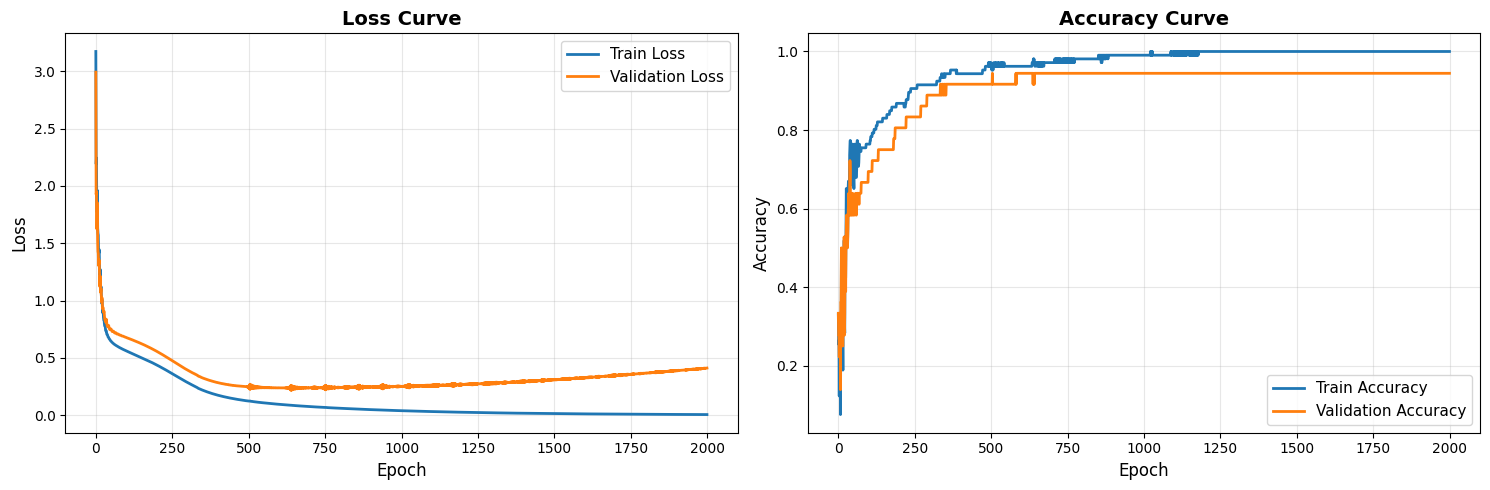


최종 학습 결과
훈련 손실: 0.0064
검증 손실: 0.4120
훈련 정확도: 1.0000 (100.00%)
검증 정확도: 0.9444 (94.44%)


In [27]:
def plot_training_history(history):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 손실(Loss) 그래프
    axes[0].plot(history['train_losses'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_losses'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # 정확도(Accuracy) 그래프
    axes[1].plot(history['train_accs'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_accs'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 최종 결과 출력
    print("\n" + "=" * 50)
    print("최종 학습 결과")
    print("=" * 50)
    print(f"훈련 손실: {history['train_losses'][-1]:.4f}")
    print(f"검증 손실: {history['val_losses'][-1]:.4f}")
    print(f"훈련 정확도: {history['train_accs'][-1]:.4f} ({history['train_accs'][-1]*100:.2f}%)")
    print(f"검증 정확도: {history['val_accs'][-1]:.4f} ({history['val_accs'][-1]*100:.2f}%)")
    print("=" * 50)

# 학습 과정 시각화
plot_training_history(history)

In [28]:
def test_model(model, inputs_test, labels_test):
    test_loss, test_acc = evaluate_model(model, inputs_test, labels_test)

    print("="*50)
    print("테스트 데이터 최종 성능")
    print("="*50)
    print(f'테스트 손실: {test_loss:.4f}')
    print(f'테스트 정확도: {test_acc:.4f} ({test_acc*100:.2f}%)')
    print("="*50)

    # 클래스 별 예측 결과
    model.eval()
    with torch.no_grad():
        outputs = model(inputs_test)
        _, predicted = torch.max(outputs, 1) # axis = 1

    # 클래스 별 정확도 계산 # 이거 뭔가 강조함. # 클래스가 뭔데요? -> 각 정답을 클래스라고 함
    for class_idx in range(3):
        class_mask = (labels_test == class_idx)
        class_correct = (predicted[class_mask] == labels_test[class_mask]).sum().item()
        class_total = class_mask.sum().item()
        class_accuracy = class_correct / class_total if class_total > 0 else 0 # 뒤 조건은 zero머시기 에러 방지
        print(f'클래스: {class_idx} 정확도: {class_accuracy:.4f}')


In [29]:
# 테스트 평가
test_model(model, inputs_test, labels_test)

테스트 데이터 최종 성능
테스트 손실: 0.1534
테스트 정확도: 0.9444 (94.44%)
클래스: 0 정확도: 1.0000
클래스: 1 정확도: 1.0000
클래스: 2 정확도: 0.8000


예측 예시

In [32]:
def predict_sample(model, inputs, labels, sample_idx=0):
    # 개별 샘플에 대한 예측 및 확률 출력

    model.eval()
    # 단일 샘플 선택(배치차원 추가)
    sample_input=inputs[sample_idx:sample_idx+1]
    true_label=labels[sample_idx].item()

    with torch.no_grad():
        output=model(sample_input)

        probabilities=torch.softmax(output, dim=1)[0]
        # softmax 적용, 확률 계산

        # 예측 클래스
        predicted=torch.argmax(probabilities).item()

    for i, prob in enumerate(probabilities):
        print(f'클래스 {i}: {prob:.4f}({prob*100:.2f}%)')


# 테스트 샘플 예측
predict_sample(model, inputs_test, labels_test, sample_idx=0)

클래스 0: 1.0000(100.00%)
클래스 1: 0.0000(0.00%)
클래스 2: 0.0000(0.00%)


In [31]:
predict_sample(model, inputs_test, labels_test, sample_idx=3)

클래스 0: 0.0000(0.00%)
클래스 1: 1.0000(100.00%)
클래스 2: 0.0000(0.00%)


In [ ]:
# eos